Se debe desarrollar un programa que permita clasificar los estados en diferentes categorías, dividiéndolos en zonas de baja peligrosidad y alta peligrosidad. Este proyecto debe ser ejecutado en un Notebook de Colab.
No es necesario aplicar múltiples modelos de clustering, ¡con aplicar uno de ellos está más que bien!
Dentro del Notebook, es importante que cada paso del proceso esté acompañado por bloques de texto que expliquen el razonamiento detrás de las decisiones tomadas. Se debe detallar por qué se eligieron ciertas técnicas, métodos o parámetros y cuál es su relevancia en el contexto del proyecto. Además, es necesario documentar los desafíos o inconvenientes que surgieron durante el desarrollo, proporcionando una visión clara y completa del proceso de diseño e implementación de la solución.


In [ ]:
#descargamos desde git hub el archivo csv con los datos a utilizar
!wget https://raw.githubusercontent.com/ricardoherbas/trayecto_f_LABORATORIO2/refs/heads/main/Crimenes.csv

--2025-11-08 23:08:36--  https://raw.githubusercontent.com/ricardoherbas/trayecto_f_LABORATORIO2/refs/heads/main/Crimenes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1328 (1.3K) [text/plain]
Saving to: ‘Crimenes.csv’

Crimenes.csv        100%[===================>]   1.30K  --.-KB/s    in 0s      

2025-11-08 23:08:36 (75.1 MB/s) - ‘Crimenes.csv’ saved [1328/1328]



In [ ]:
#importamos la biblioteca pandas para manipular el archivo csv en un dataframe
import pandas as pd

df_crimenes=pd.read_csv("/content/Crimenes.csv")
df_crimenes

,Estado,Asesinatos,Asaltos,Poblacion Urbana,Violaciones
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6
5,Colorado,7.9,204,78,38.7
6,Connecticut,3.3,110,77,11.1
7,Delaware,5.9,238,72,15.8
8,Florida,15.4,335,80,31.9
9,Georgia,17.4,211,60,25.8


observamos los datos de cada columna del dataframe anterior para analizar que datos pueden servir para entrenar el modelo kmeans

In [ ]:
#verificamos que no haya datos nulos
df_crimenes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Estado            50 non-null     object 
 1   Asesinatos        50 non-null     float64
 2   Asaltos           50 non-null     int64  
 3   Poblacion Urbana  50 non-null     int64  
 4   Violaciones       50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [ ]:
#cambiamos el tipo de dato de la columna estado a string
df_crimenes["Estado"]=df_crimenes["Estado"].astype("string")
df_crimenes.dtypes

,0
Estado,string[python]
Asesinatos,float64
Asaltos,int64
Poblacion Urbana,int64
Violaciones,float64


In [ ]:
#creamos una copia para no modificar el dataframe original
df_copia=df_crimenes.copy()
filas=df_copia.shape[0]
columnas=df_copia.shape[1]
print(f"FILAS: {filas}\nCOLUMNAS: {columnas}")

FILAS: 50
COLUMNAS: 5


notamos que son pocos datos y que coinciden con la cantidad total de los estados en EEUU

In [ ]:
#preparamos el dataframe para el modelo kmeans eliminando la columna "Estado" y "Poblacion Urbana"
df_para_kmeans=df_copia.drop(columns=["Estado","Poblacion Urbana"])
df_para_kmeans

,Asesinatos,Asaltos,Violaciones
0,13.2,236,21.2
1,10.0,263,44.5
2,8.1,294,31.0
3,8.8,190,19.5
4,9.0,276,40.6
5,7.9,204,38.7
6,3.3,110,11.1
7,5.9,238,15.8
8,15.4,335,31.9
9,17.4,211,25.8


 en el dataframe anterior eliminamos las columnas "Estado" y "Poblacion Urbana" para reducir el ruido y evitar posibles solapamientos en el modelo de clustering, priorizando las columnas directamente relacionadas con la peligrosidad

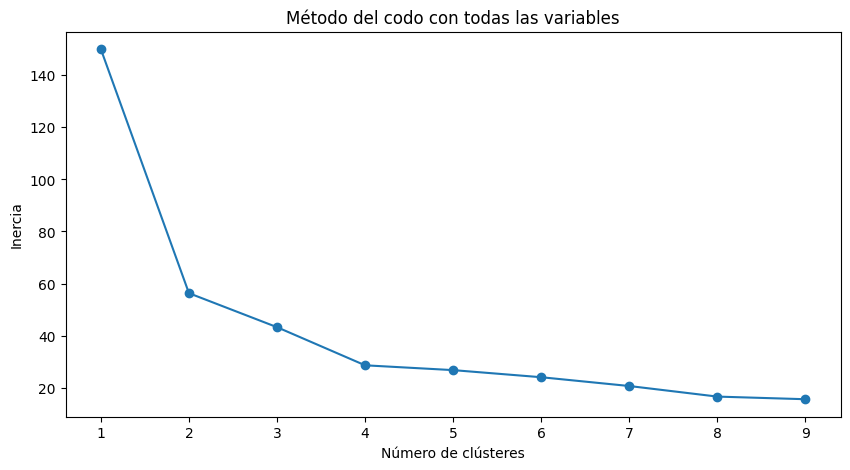

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Escalar datos
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_para_kmeans[["Asesinatos","Asaltos","Violaciones"]])

# Método del codo
inertia = []
for k in range(1, 10):
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(x_scaled)
    inertia.append(modelo.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 10), inertia, marker='o')
plt.title("Método del codo con todas las variables")
plt.xlabel("Número de clústeres")
plt.ylabel("Inercia")
plt.show()

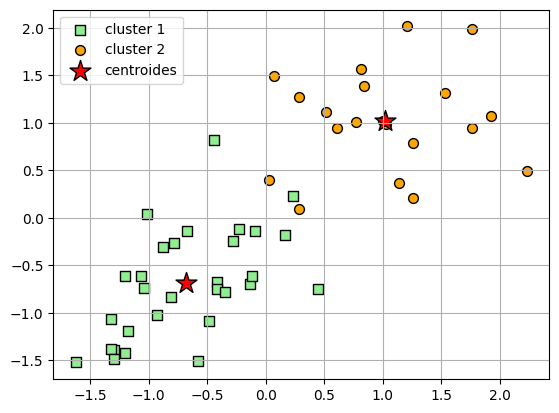

In [ ]:
#elegimos 2 clusters para el modelo
kn = KMeans(n_clusters=2, random_state=42)
Y_kn = kn.fit_predict(x_scaled)

plt.scatter(x_scaled[Y_kn == 0, 0], x_scaled[Y_kn == 0, 1], s=50, c='lightgreen', marker='s', edgecolors='black', label='cluster 1')
plt.scatter(x_scaled[Y_kn == 1, 0], x_scaled[Y_kn == 1, 1], s=50, c='orange', marker='o', edgecolors='black', label='cluster 2')

#graficar los centroides
plt.scatter(kn.cluster_centers_[:, 0], kn.cluster_centers_[:, 1], s=250, marker='*', c='red', edgecolors='black', label='centroides')
plt.legend(scatterpoints=1)
plt.grid()

In [ ]:
#calculamos el score del modelo
from sklearn.metrics import silhouette_score
score = silhouette_score(x_scaled, Y_kn)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.5238335497369087


In [ ]:
#creamos una nueva columna en el dataframe "df_para_Kmeans" llamada "Grupo" donde van las etiquetas correspondientes a cada Estado
df_para_kmeans["Grupo"] =Y_kn
df_para_kmeans

In [ ]:
#calculamos las medias estadisticas de cada grupo para visualizar que grupo es de alta peligrosidad y que grupo es de baja peligrosidad
df_para_kmeans.groupby("Grupo").mean()

en el dataframe anterior se puede ver que el grupo "0" es de BAJA peligrosidad y el grupo "1" es de ALTA peligrosidad

In [ ]:
#creamos un nuevo dataframe "df_grupos" para mostrar la cantidad de Estados por grupo
df_grupos=df_para_kmeans["Grupo"].value_counts().reset_index()
df_grupos.columns=["Grupo","cantidad"]
df_grupos

,Grupo,cantidad
0,0,30
1,1,20


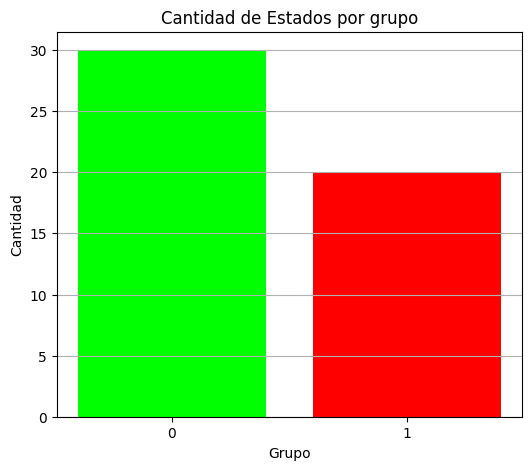

In [ ]:
# Gráfico de barras de la cantidad de Estados por grupo
plt.figure(figsize=(6,5))
colores = ['lime' if grupo == 0 else 'red' for grupo in df_grupos["Grupo"]]
plt.bar(df_grupos["Grupo"], df_grupos["cantidad"], color=colores)

plt.title("Cantidad de Estados por grupo")
plt.xlabel("Grupo")
plt.ylabel("Cantidad")
plt.xticks([0, 1])
plt.grid(axis="y")
plt.show()

In [ ]:
#calculamos el porcentaje de Estados por grupo en una nueva columna llamada "porcentaje"
df_grupos["porcentaje"]=(df_grupos["cantidad"]/df_grupos["cantidad"].sum()*100)
df_grupos

,Grupo,cantidad,porcentaje
0,0,30,60.0
1,1,20,40.0


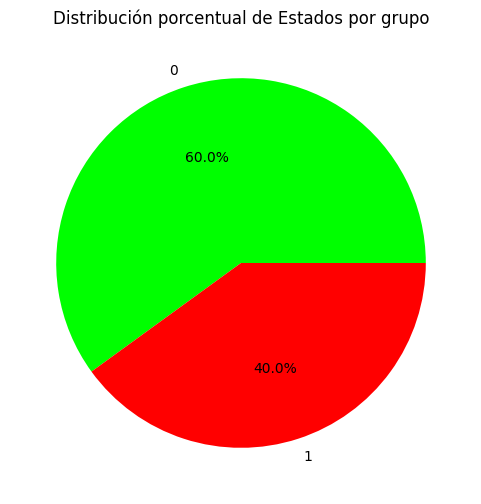

In [ ]:
# grafico del porcentaje de Estados por grupo
plt.figure(figsize=(6,6))
colores = ['lime', 'red']
plt.pie(df_grupos["porcentaje"], labels=df_grupos["Grupo"], autopct="%1.1f%%",colors=colores)
plt.title("Distribución porcentual de Estados por grupo")
plt.show()

In [ ]:
#agregamos la columna grupo al dataframe df_copia
df_copia["grupo"]=Y_kn
df_copia

,Estado,Asesinatos,Asaltos,Poblacion Urbana,Violaciones,grupo
0,Alabama,13.2,236,58,21.2,1
1,Alaska,10.0,263,48,44.5,1
2,Arizona,8.1,294,80,31.0,1
3,Arkansas,8.8,190,50,19.5,0
4,California,9.0,276,91,40.6,1
5,Colorado,7.9,204,78,38.7,1
6,Connecticut,3.3,110,77,11.1,0
7,Delaware,5.9,238,72,15.8,0
8,Florida,15.4,335,80,31.9,1
9,Georgia,17.4,211,60,25.8,1


In [ ]:
#instalamos la biblioteca us para abreviar los nombres de los estados
!pip install us

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 25.9 MB/s eta 0:00:00


In [ ]:
#importamos las bibliotecas para graficar
import plotly.express as px
import us

#creamos un nuevo dataframe con dos columnas "Estado" y "grupo" del dataframe "df_copia"
df = df_copia[["Estado","grupo"]].copy()

#le agregamos al dataframe "df" la columna "Abreviacion" rellenandola utilizando la biblioteca "us" para abreviar los nombres de los estados
df['Abreviacion'] = df['Estado'].apply(lambda x: us.states.lookup(x).abbr if us.states.lookup(x) else None)

#definimos los colores personalizados: 0 = verde, 1 = rojo
colores = [[0, 'lime'], [1, 'red']]

fig = px.choropleth(df,locations='Abreviacion',locationmode='USA-states',color='grupo',scope='usa',color_continuous_scale=colores,hover_name='Estado',
                    title='Mapa de EE.UU. según grupo de BAJA PELIGROSIDAD(verde)Y de ALTA PELIGROSIDAD(rojo)',labels={'grupo': 'Grupo'})

fig.update_traces(marker_line_color='white', marker_line_width=1)
fig.show()